In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

import joblib
# import matplotlib.colors as ListedColormap

plt.style.use("fivethirtyeight")


In [50]:
from matplotlib.colors import ListedColormap

In [24]:
class Perceptron:
    def __init__(self, eta: float = None, epochs: int = None):
        self.weights = np.random.randn(3) * 1e-4 #small random weights
        is_training = (eta is not None) and (epochs is not None)
        if is_training:
            print(f"Initial weights before training: {self.weights}")

        self.eta = eta
        self.epochs = epochs
              
    def _z_outcome(self, inputs, weights):
        return np.dot(inputs, weights)

    def activation_function(self, z):
        return np.where(z > 0, 1, 0) 

    def fit(self, X, y):
        self.X = X
        self.y = y

        X_with_bias = np.c_[self.X, -np.ones((len(self.X), 1))] #add a bias column of -1's to X
        print(f"X with bias: \n{X_with_bias}")
        
        for epoch in range(self.epochs):
            print("--"*10)
            print(f"for epoch >> {epoch+1}")
            print("--"*10)
            
            z = self._z_outcome(X_with_bias, self.weights)
            y_hat = self.activation_function(z)
            print(f"predicted value after forward pass: \n{y_hat}")

            self.error = self.y - y_hat
            print(f"error: \n{self.error}")

            self.weights = self.weights + self.eta * np.dot(X_with_bias.T, self.error)
            print(f"updated weights after epoch {epoch+1}/{self.epochs} : \n{self.weights}")
            print("##"*10)

    def predict(self, X):
        X_with_bias = np.c_[X, -np.ones((len(X), 1))] 
        z = self._z_outcome(X_with_bias, self.weights)
        return self.activation_function(z)

    def total_loss(self):
        total_loss = np.sum(self.error)
        print(f"\ntotal loss: {total_loss}\n")
        return total_loss

    def _create_dir_return_path(self, model_dir, filename):
        os.makedirs(model_dir, exist_ok=True)
        return os.path.join(model_dir, filename)

    def save(self, filename, model_dir=None):
        if model_dir is not None:
            model_file_path = self._create_dir_return_path(model_dir, filename)
        else:
            model_file_path = self._create_dir_return_path("models", filename)

        joblib.dump(self, model_file_path)

    def load(self, filepath):
        return joblib.load(filepath)

In [25]:
AND = {
    "x1": [0,0,1,1],
    "x2": [0,1,0,1],
    "y": [0,0,0,1],
}

OR = {
    "x1": [0,0,1,1],
    "x2": [0,1,0,1],
    "y": [0,1,1,1],
}

XOR = {
    "x1": [0,0,1,1],
    "x2": [0,1,0,1],
    "y": [0,1,1,0],
}

In [26]:
def prepare_data(df, target_col="y"):
    X = df.drop(target_col, axis=1)
    y = df[target_col]
    return X, y

In [27]:
df_AND = pd.DataFrame(AND)
df_AND

,x1,x2,y
0,0,0,0
1,0,1,0
2,1,0,0
3,1,1,1


In [28]:
X, y = prepare_data(df_AND)
ETA = 0.1 # between 0 and 1
EPOCHS = 10
model_and = Perceptron(eta=ETA, epochs=EPOCHS)
model_and.fit(X, y)
_ = model_and.total_loss()

Initial weights before training: [5.92872148e-05 5.39861680e-05 1.01796149e-04]
X with bias: 
[[ 0.  0. -1.]
 [ 0.  1. -1.]
 [ 1.  0. -1.]
 [ 1.  1. -1.]]
--------------------
for epoch >> 1
--------------------
predicted value after forward pass: 
[0 0 0 1]
error: 
0    0
1    0
2    0
3    0
Name: y, dtype: int64
updated weights after epoch 1/10 : 
[5.92872148e-05 5.39861680e-05 1.01796149e-04]
####################
--------------------
for epoch >> 2
--------------------
predicted value after forward pass: 
[0 0 0 1]
error: 
0    0
1    0
2    0
3    0
Name: y, dtype: int64
updated weights after epoch 2/10 : 
[5.92872148e-05 5.39861680e-05 1.01796149e-04]
####################
--------------------
for epoch >> 3
--------------------
predicted value after forward pass: 
[0 0 0 1]
error: 
0    0
1    0
2    0
3    0
Name: y, dtype: int64
updated weights after epoch 3/10 : 
[5.92872148e-05 5.39861680e-05 1.01796149e-04]
####################
--------------------
for epoch >> 4
-----------

In [29]:
df_OR = pd.DataFrame(OR)
df_OR

,x1,x2,y
0,0,0,0
1,0,1,1
2,1,0,1
3,1,1,1


In [32]:
X, y = prepare_data(df_OR)
ETA = 0.1 # between 0 and 1
EPOCHS = 10
model_or = Perceptron(eta=ETA, epochs=EPOCHS)
model_or.fit(X, y)
_ = model_or.total_loss()

Initial weights before training: [ 1.21924641e-04 -1.71026526e-04  3.73654669e-05]
X with bias: 
[[ 0.  0. -1.]
 [ 0.  1. -1.]
 [ 1.  0. -1.]
 [ 1.  1. -1.]]
--------------------
for epoch >> 1
--------------------
predicted value after forward pass: 
[0 0 1 0]
error: 
0    0
1    1
2    0
3    1
Name: y, dtype: int64
updated weights after epoch 1/10 : 
[ 0.10012192  0.19982897 -0.19996263]
####################
--------------------
for epoch >> 2
--------------------
predicted value after forward pass: 
[1 1 1 1]
error: 
0   -1
1    0
2    0
3    0
Name: y, dtype: int64
updated weights after epoch 2/10 : 
[ 0.10012192  0.19982897 -0.09996263]
####################
--------------------
for epoch >> 3
--------------------
predicted value after forward pass: 
[1 1 1 1]
error: 
0   -1
1    0
2    0
3    0
Name: y, dtype: int64
updated weights after epoch 3/10 : 
[1.00121925e-01 1.99828973e-01 3.73654669e-05]
####################
--------------------
for epoch >> 4
--------------------
predi

In [33]:
df_XOR = pd.DataFrame(XOR)
df_XOR

,x1,x2,y
0,0,0,0
1,0,1,1
2,1,0,1
3,1,1,0


In [36]:
X, y = prepare_data(df_XOR)
ETA = 0.1 # between 0 and 1
EPOCHS = 10
model_XOR = Perceptron(eta=ETA, epochs=EPOCHS)
model_XOR.fit(X, y)
_ = model_XOR.total_loss()

Initial weights before training: [-0.00010515  0.0001172  -0.00026978]
X with bias: 
[[ 0.  0. -1.]
 [ 0.  1. -1.]
 [ 1.  0. -1.]
 [ 1.  1. -1.]]
--------------------
for epoch >> 1
--------------------
predicted value after forward pass: 
[1 1 1 1]
error: 
0   -1
1    0
2    0
3   -1
Name: y, dtype: int64
updated weights after epoch 1/10 : 
[-0.10010515 -0.0998828   0.19973022]
####################
--------------------
for epoch >> 2
--------------------
predicted value after forward pass: 
[0 0 0 0]
error: 
0    0
1    1
2    1
3    0
Name: y, dtype: int64
updated weights after epoch 2/10 : 
[-0.00010515  0.0001172  -0.00026978]
####################
--------------------
for epoch >> 3
--------------------
predicted value after forward pass: 
[1 1 1 1]
error: 
0   -1
1    0
2    0
3   -1
Name: y, dtype: int64
updated weights after epoch 3/10 : 
[-0.10010515 -0.0998828   0.19973022]
####################
--------------------
for epoch >> 4
--------------------
predicted value after forw

In [38]:
model_and.save("and_model.pkl")
model_or.save("or_model.pkl")
model_XOR.save("xor_model.pkl")

In [40]:
reload_model_and = Perceptron().load(filepath="models/and_model.pkl")

In [43]:
reload_model_and.predict(X=[[1, 0]])

array([1])

In [47]:
reload_model_or = Perceptron().load(filepath="models/or_model.pkl")
reload_model_or.predict(X=[[0, 1]])

array([1])

In [48]:
def save_plot(df, model, filename="plot.png", plot_dir="plots"):
    def _create_base_plot(df):
        df.plot(kind="scatter", x="x1", y="x2", c=df["y"], s=100, cmap="spring")
        plt.axhline(y=0, color="black", linestyle="dashed", linewidth=1)
        plt.axvline(x=0, color="black", linestyle="dashed", linewidth=1)

        figure = plt.gcf()
        figure.set_size_inches(10, 8)

    def _plot_decision_regions(X, y, classifier, resolution=0.02):
        colors = ("cyan", "lightgreen")
        cmap = ListedColormap(colors)

        X = X.values # as an array
        x1 = X[:, 0]
        x2 = X[:, 1]

        x1_min, x1_max = x1.min() - 1, x1.max() + 1
        x2_min, x2_max = x2.min() - 1, x2.max() + 1

        xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution), 
                               np.arange(x2_min, x2_max, resolution))

        y_hat = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
        y_hat = y_hat.reshape(xx1.shape)

        plt.contourf(xx1, xx2, y_hat, alpha=0.3, cmap=cmap)
        plt.xlim(xx1.min(), xx1.max())
        plt.ylim(xx2.min(), xx2.max())

        plt.plot()
        

    X, y = prepare_data(df)
    _create_base_plot(df)
    _plot_decision_regions(X, y, model)

    os.makedirs(plot_dir, exist_ok=True)
    plot_file_path = os.path.join(plot_dir, filename)
    plt.savefig(plot_file_path)
    plt.show()

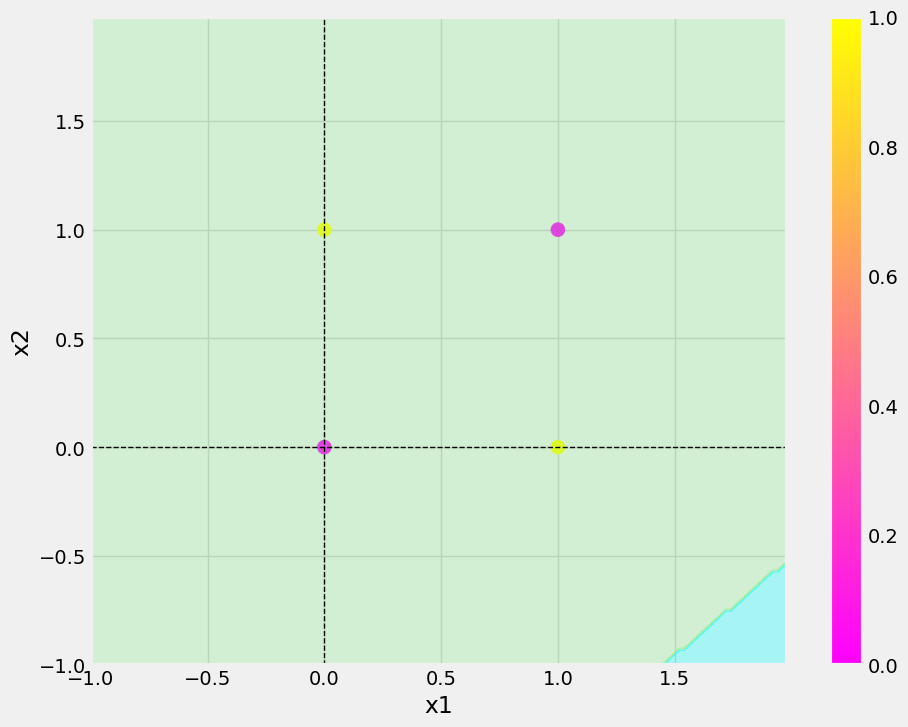

In [53]:
save_plot(df_XOR, model_XOR, filename="xor_plot.png")